In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc
from scripts.Hamiltonian import Hamiltonian


In [2]:
width = 40
X, Y = width, 200
lattice = Lattice(X, Y)

t = 1
T = 0.01

muP = 1.8 * t
mu = np.ones(lattice.X) * muP

U = None
V = None

V0 = 2 * t
V_prime = V0 * np.ones(lattice.X)

H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, g_t=V,
                Fuu_init=[0.01, -0.01, 0.01j, -0.01j],
                Fdd_init=[0.01, -0.01, 0.01j, -0.01j])


In [3]:
bdg_sc(H, atol=1e-3, rtol=1e-1, maxiter=1000, temperature=T,verbose=True)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 3.671780307527489e-17
Relative error: 3.6717803075274894e-05
Average old: 0j
Average: (2.576946106234335e-18+0j)
F_xplus:
Absolute error: 3.59802717498527e-17
Relative error: 3.59802717498527e-05
Average old: 0j
Average: (-2.5361789381752725e-18+0j)
F_xmin:
Absolute error: 3.775632382234782e-17
Relative error: 3.775632382234781e-05
Average old: 0j
Average: (-1.2726631210663652e-18+0j)
F_yplus:
Absolute error: 3.8148955518920424e-17
Relative error: 3.814895551892042e-05
Average old: 0j
Average: (-9.698069114524772e-20-1.0708290965852009e-18j)
F_ymin:
Absolute error: 3.8148955518920424e-17
Relative error: 3.814895551892042e-05
Average old: 0j
Average: (-9.698069114524772e-20+1.0708290965852009e-18j)
Fuu_xplus:
Absolute error: 0.010649681193195645
Relative error: 1.0649681192130676
Average old: (0.01+0j)
Average: (0.010545204414192186+0j)
Fuu_xmin:
Absolute error: 0.010649681193195645
Relative error: 1.0649681194260614
Average old: (-0.01+0j)
Average: (-0.0105452044141

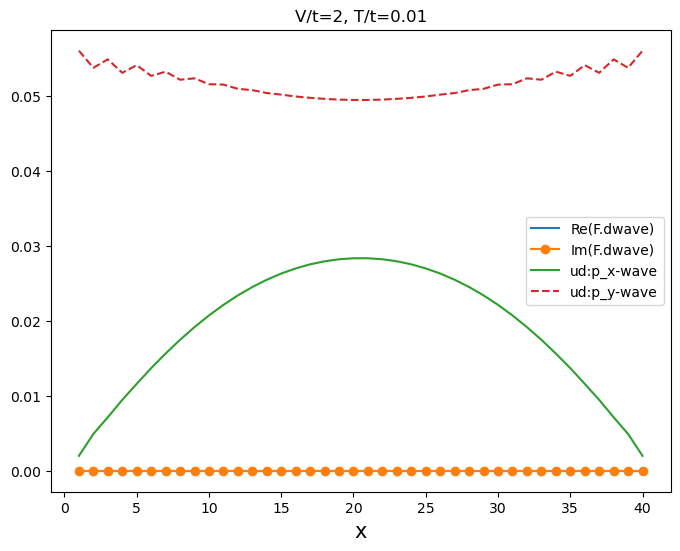

In [4]:
x = np.arange(1, width + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"V/t={V0}, T/t={T}")
axs.plot(x, np.real(F.dwave), label="Re(F.dwave)")
axs.plot(x, np.imag(F.dwave), '-o', label="Im(F.dwave)")
axs.plot(x, np.abs(Fuu.px), label="ud:p_x-wave")
axs.plot(x, np.abs(Fuu.py), "--", label="ud:p_y-wave")
axs.set_xlabel("x", fontsize=15)
# axs.axhline(0.33, linestyle='--', color="red")
axs.legend()
plt.show()

In [5]:
print(F.py[X//2])
print(F.px[X//2])


(5.585196838722984e-32-9.22288160838179e-18j)
(-2.3518048478237632e-18+8.90155958462988e-31j)
